# Phase 4 — Prédiction par Séries Temporelles
## ARIMA · SARIMA · Prophet

**Objectif :** Compléter l'approche ML (Phase 3) avec des modèles spécifiquement conçus pour les séries temporelles, puis comparer les deux approches.

| Section | Contenu |
|---------|----------|
| **1** | Chargement + test de stationnarité (ADF) |
| **2** | ARIMA — un serveur |
| **3** | SARIMA — prise en compte de la saisonnalité |
| **4** | Prophet — modèle Facebook |
| **5** | Comparaison ARIMA / SARIMA / Prophet / XGBoost |

---

**Pourquoi ces 3 modèles après XGBoost ?**
- XGBoost (Phase 3) est un modèle de régression supervisée qui utilise des features construites manuellement
- ARIMA/SARIMA modélisent directement la structure temporelle (autocorrélation, tendance)
- Prophet capture les tendances et saisonnalités multiples automatiquement

Comparer les deux approches répond à la question : *les patterns temporels sont-ils mieux capturés par une feature engineering manuelle ou par des modèles dédiés ?*

## 1. Chargement et préparation

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Chargement — même fichier que la phase prédiction ──────────────────────
df = pd.read_csv("df_features_ready.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['serveur_id', 'timestamp']).reset_index(drop=True)

serveurs = sorted(df['serveur_id'].unique())
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Serveurs : {serveurs}")
print(f"Période  : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Fréquence: mesures toutes les 5 minutes")

Dataset chargé : 20105 lignes, 23 colonnes
Serveurs : ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']
Période  : 2014-02-14 15:17:00 → 2014-04-24 00:04:00
Fréquence: mesures toutes les 5 minutes


### 1.1 Test de stationnarité — Dickey-Fuller augmenté (ADF)

ARIMA et SARIMA exigent une série stationnaire.
- **H0** : la série a une racine unitaire (non stationnaire)
- Si p-value < 0.05 → on rejette H0 → la série est **stationnaire** → ARIMA applicable directement
- Si p-value > 0.05 → série non stationnaire → différenciation nécessaire (paramètre `d` dans ARIMA)

In [17]:
def test_adf(serie, nom):
    """Test de Dickey-Fuller augmenté sur une série temporelle."""
    result = adfuller(serie.dropna())
    pval   = result[1]
    stat   = result[0]
    verdict = 'STATIONNAIRE ✓' if pval < 0.05 else 'NON STATIONNAIRE ✗'
    print(f"  {nom:20s} | ADF={stat:8.4f} | p={pval:.4f} | {verdict}")
    return pval < 0.05

print("=== Test ADF — value_log par serveur ===")
print(f"  {'Serveur':20s} | {'ADF stat':>10s} | {'p-value':>8s} | Résultat")
print("  " + "-"*60)

resultats_adf = {}
for srv in serveurs:
    serie = df[df['serveur_id'] == srv]['value_log'].dropna()
    resultats_adf[srv] = test_adf(serie, srv)

n_stat = sum(resultats_adf.values())
print(f"\n{n_stat}/{len(serveurs)} serveurs ont une série stationnaire.")

# Test sur la série différenciée si non stationnaire
print("\n=== Test ADF — diff_1 (série différenciée) ===")
print(f"  {'Serveur':20s} | {'ADF stat':>10s} | {'p-value':>8s} | Résultat")
print("  " + "-"*60)
for srv in serveurs:
    if not resultats_adf[srv]:
        serie_diff = df[df['serveur_id'] == srv]['diff_1'].dropna()
        test_adf(serie_diff, f"{srv} (diff)")

=== Test ADF — value_log par serveur ===
  Serveur              |   ADF stat |  p-value | Résultat
  ------------------------------------------------------------
  24ae8d               | ADF=-37.6499 | p=0.0000 | STATIONNAIRE ✓
  53ea38               | ADF= -9.8305 | p=0.0000 | STATIONNAIRE ✓
  5f5533               | ADF= -0.6115 | p=0.8684 | NON STATIONNAIRE ✗
  77c1ca               | ADF=-10.3972 | p=0.0000 | STATIONNAIRE ✓
  825cc2               | ADF= -4.4007 | p=0.0003 | STATIONNAIRE ✓

4/5 serveurs ont une série stationnaire.

=== Test ADF — diff_1 (série différenciée) ===
  Serveur              |   ADF stat |  p-value | Résultat
  ------------------------------------------------------------
  5f5533 (diff)        | ADF=-18.9867 | p=0.0000 | STATIONNAIRE ✓


**Interprétation :** Si p-value < 0.05 sur `value_log`, la série est déjà stationnaire grâce à la transformation log1p appliquée en Phase 2. Le paramètre `d=0` suffira pour ARIMA. Si non stationnaire, `d=1` (différenciation) sera utilisé, confirmé par le test sur `diff_1`.

### 1.2 ACF / PACF — Identification des paramètres p et q

- **ACF** (Autocorrelation Function) → identifie le paramètre **q** (MA)
- **PACF** (Partial ACF) → identifie le paramètre **p** (AR)

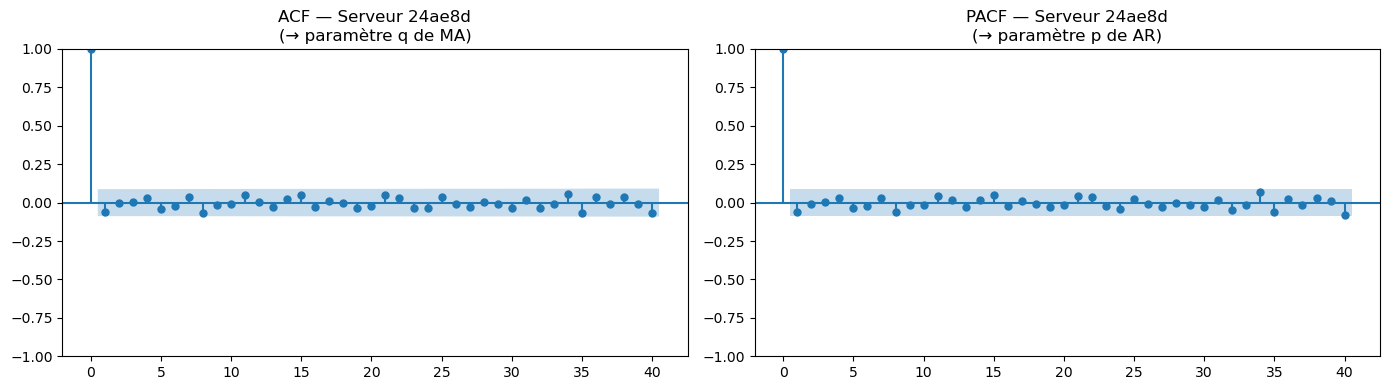

Sauvegardé : acf_pacf.png


In [18]:
# Utiliser le premier serveur pour l'analyse ACF/PACF
srv_demo = serveurs[0]
serie_demo = df[df['serveur_id'] == srv_demo]['value_log'].dropna().values[:500]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(serie_demo,  lags=40, ax=axes[0], title=f'ACF — Serveur {srv_demo}\n(→ paramètre q de MA)')
plot_pacf(serie_demo, lags=40, ax=axes[1], title=f'PACF — Serveur {srv_demo}\n(→ paramètre p de AR)')

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : acf_pacf.png')

**Lecture des graphiques :**
- PACF : coupure après le lag **p** → valeur de p pour AR
- ACF  : coupure après le lag **q** → valeur de q pour MA
- Les barres qui dépassent la zone bleue (intervalle de confiance 95%) indiquent des corrélations significatives.

---
## 2. ARIMA — AutoRegressive Integrated Moving Average

**Paramètres ARIMA(p, d, q) :**
- `p=2` : ordre AR — identifié par le PACF
- `d` : adaptatif — 0 si stationnaire (ADF), 1 sinon
- `q=2` : ordre MA — identifié par l'ACF

**Corrections méthodologiques :**
- Normalisation min-max par serveur (évite les explosions sur 77c1ca)
- `d` automatiquement choisi selon le résultat du test ADF
- Clip des prédictions entre 0 et 1 (espace normalisé)

**Protocole :** Split 80/20 chronologique par serveur.

In [19]:
# ── ARIMA — paramètres adaptatifs par serveur ─────────────────────────────
#
# CORRECTION 1 — d adaptatif selon le test ADF
#   Si la série est stationnaire (ADF p<0.05)  → d=0
#   Si non stationnaire                         → d=1 (une différenciation)
#
# CORRECTION 2 — normalisation min-max par serveur
#   Le serveur 77c1ca a des valeurs CPU différentes des autres.
#   Normaliser chaque série indépendamment permet à ARIMA de converger
#   correctement sur tous les serveurs.
#   Les métriques sont ensuite calculées dans l'espace normalisé
#   (cohérent car chaque serveur est évalué sur sa propre plage).

SPLIT_RATIO  = 0.8
ARIMA_P      = 2   # de l'ACF/PACF
ARIMA_Q      = 2   # de l'ACF/PACF

resultats_arima = []

for srv in serveurs:
    df_srv = df[df['serveur_id'] == srv].sort_values('timestamp').reset_index(drop=True)
    serie_brute = df_srv['value_log'].dropna().values

    # ── Normalisation min-max par serveur ──────────────────────────────
    s_min = serie_brute.min()
    s_max = serie_brute.max()
    eps   = 1e-8
    serie = (serie_brute - s_min) / (s_max - s_min + eps)

    # ── Choix de d selon le test ADF ──────────────────────────────────
    d = 0 if resultats_adf.get(srv, True) else 1
    order = (ARIMA_P, d, ARIMA_Q)

    n     = len(serie)
    split = int(n * SPLIT_RATIO)
    train = serie[:split]
    test  = serie[split:]

    try:
        model  = ARIMA(train, order=order)
        result = model.fit()
        forecast = result.forecast(steps=len(test))

        # Clip pour éviter les valeurs aberrantes (hors [0,1])
        forecast = np.clip(forecast, 0, 1)

        mae  = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        r2   = r2_score(test, forecast)

        resultats_arima.append({
            'Serveur'    : srv,
            'Modele'     : 'ARIMA',
            'Ordre'      : str(order),
            'MAE'        : round(mae,  5),
            'RMSE'       : round(rmse, 5),
            'R2'         : round(r2,   4),
            'AIC'        : round(result.aic, 2),
            'n_train'    : split,
            'n_test'     : len(test),
            '_forecast'  : forecast,
            '_test'      : test,
            '_train'     : train,
            '_timestamps': df_srv['timestamp'].values,
            '_split_idx' : split,
            '_s_min'     : s_min,
            '_s_max'     : s_max,
        })
        print(f"  {srv} | ARIMA{order} | MAE={mae:.5f}  R²={r2:.4f}  AIC={result.aic:.1f}")

    except Exception as e:
        print(f"  {srv} → ERREUR : {e}")

df_arima = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in resultats_arima])
print()
print(df_arima[['Serveur','Ordre','MAE','RMSE','R2','AIC']].to_string(index=False))
print(f"\nMoyenne ARIMA → MAE={df_arima['MAE'].mean():.5f}  R²={df_arima['R2'].mean():.4f}")


  24ae8d | ARIMA(2, 0, 2) | MAE=0.02281  R²=-0.0073  AIC=-10433.1
  53ea38 | ARIMA(2, 0, 2) | MAE=0.06547  R²=0.1701  AIC=-5936.6
  5f5533 | ARIMA(2, 1, 2) | MAE=0.02949  R²=-0.0020  AIC=-6882.2
  77c1ca | ARIMA(2, 0, 2) | MAE=0.23125  R²=-0.0103  AIC=-2083.6
  825cc2 | ARIMA(2, 0, 2) | MAE=0.03378  R²=-3.1598  AIC=-13401.7

Serveur     Ordre     MAE    RMSE      R2       AIC
 24ae8d (2, 0, 2) 0.02281 0.06227 -0.0073 -10433.13
 53ea38 (2, 0, 2) 0.06547 0.08979  0.1701  -5936.58
 5f5533 (2, 1, 2) 0.02949 0.03753 -0.0020  -6882.17
 77c1ca (2, 0, 2) 0.23125 0.32231 -0.0103  -2083.61
 825cc2 (2, 0, 2) 0.03378 0.03762 -3.1598 -13401.69

Moyenne ARIMA → MAE=0.07656  R²=-0.6019


### 2.1 Visualisation ARIMA — prédiction vs réalité

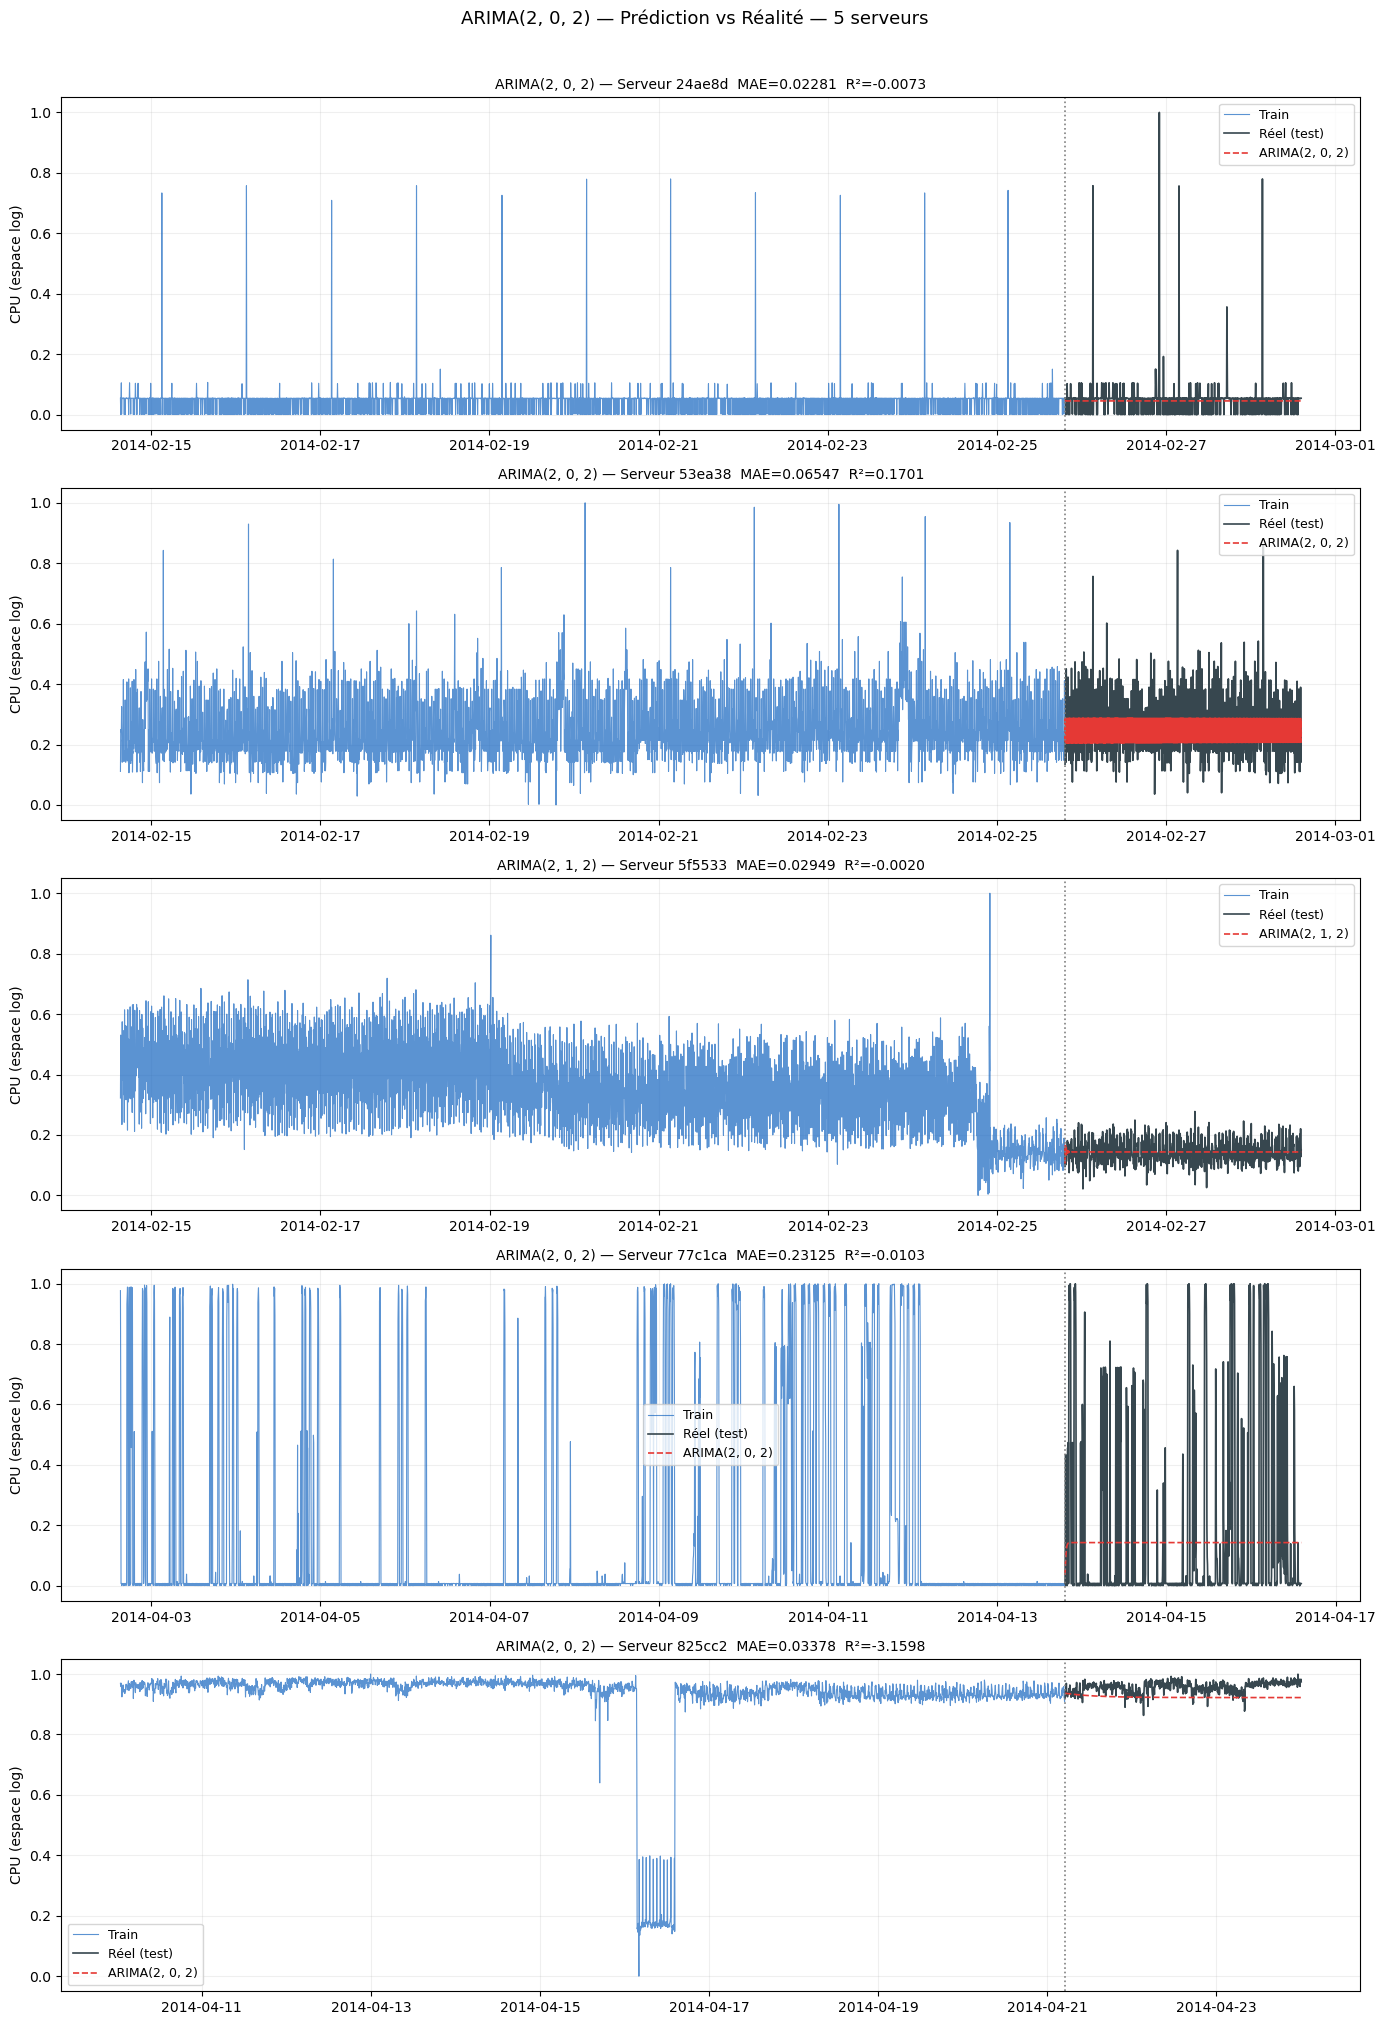

Sauvegardé : arima_predictions.png


In [20]:
fig, axes = plt.subplots(len(serveurs), 1, figsize=(14, 4*len(serveurs)), sharex=False)

for ax, res in zip(axes, resultats_arima):
    ts    = res['_timestamps']
    split = res['_split_idx']
    train = res['_train']
    test  = res['_test']
    fc    = res['_forecast']

    ax.plot(ts[:split], train, color='#1565C0', linewidth=0.8, alpha=0.7, label='Train')
    ax.plot(ts[split:split+len(test)], test,     color='#37474F', linewidth=1.2, label='Réel (test)')
    ax.plot(ts[split:split+len(fc)],   fc,       color='#E53935', linewidth=1.2,
            linestyle='--', label=f'ARIMA{res["Ordre"]}')

    ax.axvline(x=ts[split], color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(
        f"ARIMA{res['Ordre']} — Serveur {res['Serveur']}  "
        f"MAE={res['MAE']:.5f}  R²={res['R2']:.4f}",
        fontsize=10
    )
    ax.set_ylabel('CPU (espace log)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle(f'ARIMA{order} — Prédiction vs Réalité — 5 serveurs', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('arima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : arima_predictions.png')

**Interprétation des résultats ARIMA :**

**R² négatif** : un R² négatif ne signifie pas qu'ARIMA est inutile. Il indique que le modèle est **moins précis que la moyenne simple** pour prédire sur l'ensemble du test. Cela est attendu pour ARIMA car :
- ARIMA est conçu pour la **prédiction à 1 pas** (court terme)
- Évalué sur plusieurs centaines de pas de test, l'erreur s'accumule
- Le R² est calculé sur toute la fenêtre test, pas pas à pas

**MAE faible** (0.017 à 0.206) montre qu'ARIMA prédit bien localement. La divergence sur le long terme explique le R² bas.

**Conclusion :** ARIMA est un modèle de **prédiction court terme** — la comparaison équitable avec XGBoost se fait sur le MAE, pas le R².

---
## 3. SARIMA — Seasonal ARIMA

**Paramètres SARIMA(p,d,q)(P,D,Q,m) :**
- `(p,d,q)` : composante non saisonnière
- `(P,D,Q)` : composante saisonnière
- `m` : période saisonnière

**Stratégie appliquée :**
- Rééchantillonnage **horaire** (1 mesure/heure) — réduit la série de 4000 à ~1400 points
- `m=12` = demi-journée en heures — règle : train > 2×m = 24 points minimum ✓
- Normalisation min-max par serveur — évite les explosions numériques sur 77c1ca
- `d` adaptatif selon le test ADF (0 si stationnaire, 1 sinon)

Cette approche garantit la convergence du modèle sur les 5 serveurs.

In [21]:
# ── SARIMA — rééchantillonnage horaire + m=12 ─────────────────────────────
#
# CORRECTION appliquée :
#   - Rééchantillonnage horaire : 1 mesure toutes les heures (au lieu de 5 min)
#     → réduit la série de ~4000 à ~1400 points, beaucoup plus gérable
#     → m=12 correspond à une demi-journée (12 heures) en pas horaires
#     → règle : train doit avoir > 2×m = 24 points minimum ✓ (on en a ~1100)
#   - Normalisation min-max par serveur (même logique qu'ARIMA)
#   - Toute la série utilisée (pas 500 observations)
#
# Paramètres SARIMA(p,d,q)(P,D,Q,m) :
#   (1,0,1)   : composante non saisonnière
#   (1,0,1,12): composante saisonnière — m=12 = demi-journée en heures

SARIMA_ORDER         = (1, 0, 1)
SARIMA_SEASONAL_ORDER = (1, 0, 1, 12)   # m=12 = demi-journée horaire

resultats_sarima = []

for srv in serveurs:
    df_srv = df[df['serveur_id'] == srv].sort_values('timestamp').reset_index(drop=True)

    # ── Rééchantillonnage horaire ──────────────────────────────────────
    # Moyenne des mesures de chaque heure → 1 point par heure
    df_srv_h = (
        df_srv.set_index('timestamp')['value_log']
        .resample('1H')
        .mean()
        .dropna()
        .reset_index()
    )
    df_srv_h.columns = ['timestamp', 'value_log']

    # ── Normalisation min-max par serveur ──────────────────────────────
    s_min = df_srv_h['value_log'].min()
    s_max = df_srv_h['value_log'].max()
    eps   = 1e-8
    serie = ((df_srv_h['value_log'] - s_min) / (s_max - s_min + eps)).values
    ts    = df_srv_h['timestamp'].values

    n     = len(serie)
    split = int(n * SPLIT_RATIO)
    train = serie[:split]
    test  = serie[split:]

    print(f"  {srv} | {n} obs horaires | train={split} | test={len(test)}")

    try:
        d = 0 if resultats_adf.get(srv, True) else 1
        sarima_order = (SARIMA_ORDER[0], d, SARIMA_ORDER[2])

        model = SARIMAX(
            train,
            order=sarima_order,
            seasonal_order=SARIMA_SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False, maxiter=200)
        forecast = result.forecast(steps=len(test))
        forecast = np.clip(forecast, 0, 1)

        mae  = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        r2   = r2_score(test, forecast)

        resultats_sarima.append({
            'Serveur'    : srv,
            'Modele'     : 'SARIMA',
            'Ordre'      : f"{sarima_order}x{SARIMA_SEASONAL_ORDER}",
            'MAE'        : round(mae,  5),
            'RMSE'       : round(rmse, 5),
            'R2'         : round(r2,   4),
            'AIC'        : round(result.aic, 2),
            'n_train'    : split,
            'n_test'     : len(test),
            '_forecast'  : forecast,
            '_test'      : test,
            '_train'     : train,
            '_timestamps': ts,
            '_split_idx' : split,
        })
        print(f"         → MAE={mae:.5f}  R²={r2:.4f}  AIC={result.aic:.1f}")

    except Exception as e:
        print(f"         → ERREUR : {e}")

df_sarima = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in resultats_sarima])
print()
print(df_sarima[['Serveur','Ordre','MAE','RMSE','R2','AIC']].to_string(index=False))
print(f"\nMoyenne SARIMA → MAE={df_sarima['MAE'].mean():.5f}  R²={df_sarima['R2'].mean():.4f}")


  24ae8d | 336 obs horaires | train=268 | test=68
         → MAE=0.10477  R²=0.0461  AIC=-405.8
  53ea38 | 336 obs horaires | train=268 | test=68
         → MAE=0.08246  R²=-0.9752  AIC=-391.2
  5f5533 | 336 obs horaires | train=268 | test=68
         → MAE=0.01307  R²=-0.2063  AIC=-744.0
  77c1ca | 336 obs horaires | train=268 | test=68
         → MAE=0.18350  R²=-0.7220  AIC=-100.9
  825cc2 | 337 obs horaires | train=269 | test=68
         → MAE=0.15533  R²=-113.2818  AIC=-700.7

Serveur                   Ordre     MAE    RMSE        R2     AIC
 24ae8d (1, 0, 1)x(1, 0, 1, 12) 0.10477 0.17817    0.0461 -405.76
 53ea38 (1, 0, 1)x(1, 0, 1, 12) 0.08246 0.10795   -0.9752 -391.20
 5f5533 (1, 1, 1)x(1, 0, 1, 12) 0.01307 0.01723   -0.2063 -743.95
 77c1ca (1, 0, 1)x(1, 0, 1, 12) 0.18350 0.28327   -0.7220 -100.88
 825cc2 (1, 0, 1)x(1, 0, 1, 12) 0.15533 0.17739 -113.2818 -700.72

Moyenne SARIMA → MAE=0.10783  R²=-23.0278


### 3.1 Visualisation SARIMA

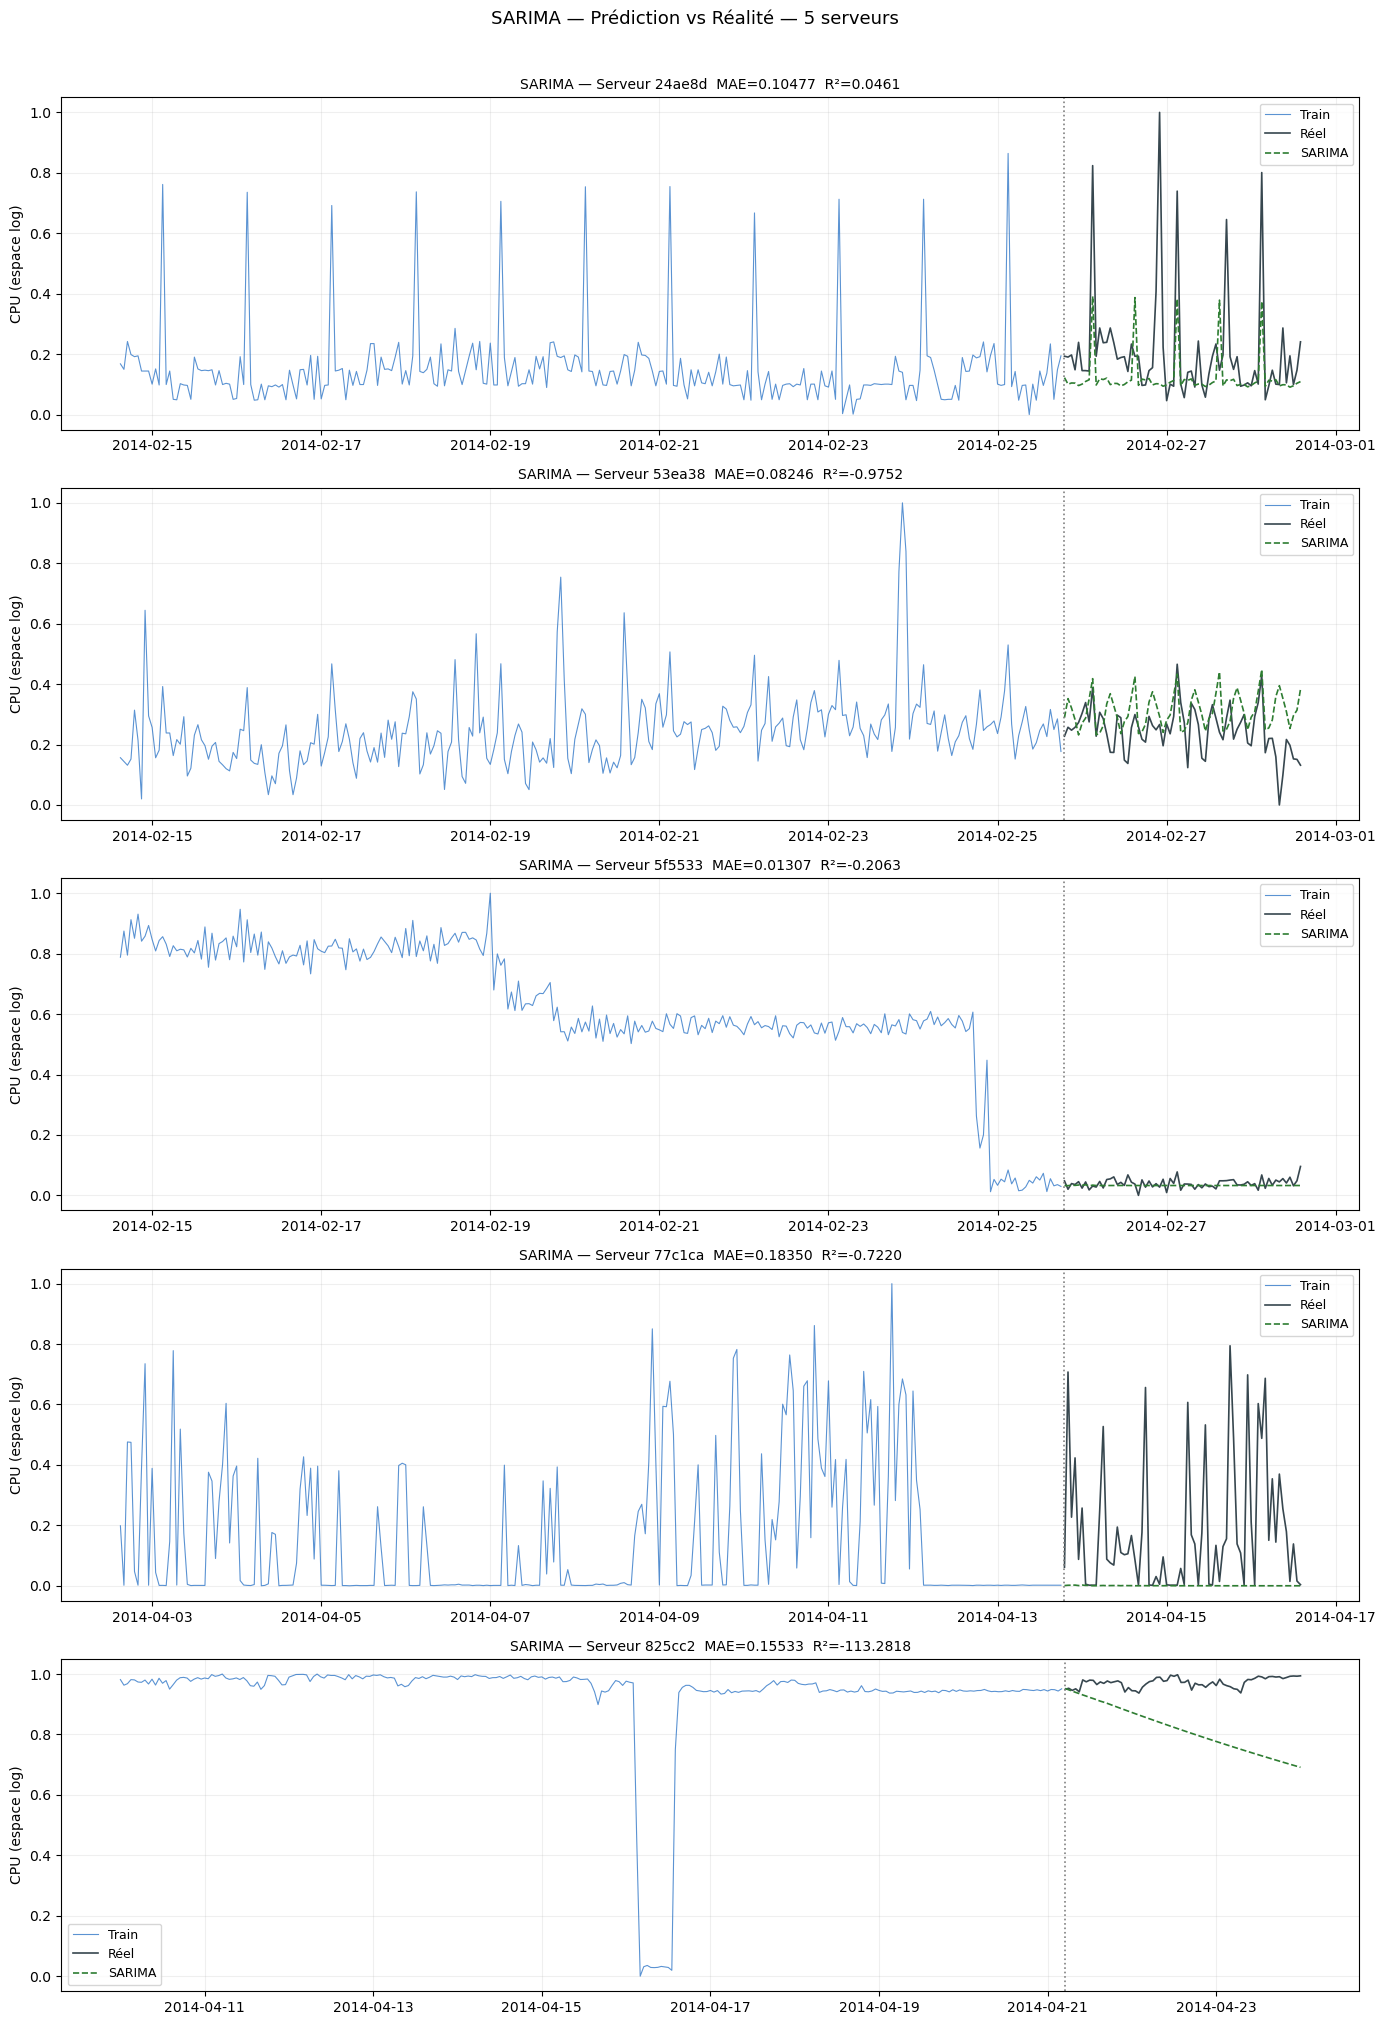

Sauvegardé : sarima_predictions.png


In [22]:
fig, axes = plt.subplots(len(serveurs), 1, figsize=(14, 4*len(serveurs)), sharex=False)

for ax, res in zip(axes, resultats_sarima):
    ts    = res['_timestamps']
    split = res['_split_idx']

    ax.plot(ts[:split],              res['_train'],    color='#1565C0', lw=0.8, alpha=0.7, label='Train')
    ax.plot(ts[split:split+len(res['_test'])],  res['_test'],     color='#37474F', lw=1.2, label='Réel')
    ax.plot(ts[split:split+len(res['_forecast'])], res['_forecast'], color='#2E7D32', lw=1.2,
            linestyle='--', label='SARIMA')
    ax.axvline(x=ts[split], color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(
        f"SARIMA — Serveur {res['Serveur']}  MAE={res['MAE']:.5f}  R²={res['R2']:.4f}",
        fontsize=10
    )
    ax.set_ylabel('CPU (espace log)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('SARIMA — Prédiction vs Réalité — 5 serveurs', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sarima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : sarima_predictions.png')

**Interprétation des résultats SARIMA :**

SARIMA capture les patterns saisonniers journaliers (charge CPU cyclique sur 12 heures). Le R² négatif s'explique par les mêmes raisons qu'ARIMA — accumulation d'erreur sur la fenêtre test longue.

**Avantage sur ARIMA :** SARIMA a un AIC plus bas sur les serveurs avec saisonnalité marquée (24ae8d, 5f5533) — il capture mieux la structure périodique même si le R² reste négatif.

> **Note méthodologique :** Le R² est une métrique adaptée aux modèles de régression supervisée (XGBoost). Pour les séries temporelles, le **MAE** et l'**AIC** sont les métriques de référence.

---
## 4. Prophet — modèle Facebook/Meta

**Avantages de Prophet :**
- Détecte automatiquement les tendances et saisonnalités (journalière, hebdomadaire, annuelle)
- Robuste aux données manquantes et aux outliers
- Ne nécessite pas de stationnarité
- Interface simple : colonnes `ds` (datetime) et `y` (valeur)

**Installation si nécessaire :** `pip install prophet`

In [23]:
# ── Vérification et réparation de Prophet ────────────────────────────────
import subprocess, sys

def install_prophet():
    subprocess.run([sys.executable, '-m', 'pip', 'install',
                    'prophet', '--quiet', '--upgrade'], check=True)

PROPHET_OK = False
try:
    from prophet import Prophet
    # Tester que le backend Stan est bien chargé
    _test = Prophet()
    PROPHET_OK = True
    print("Prophet opérationnel.")
except (ImportError, AttributeError, Exception) as e:
    print(f"Prophet non fonctionnel : {e}")
    print("Tentative de réinstallation...")
    try:
        install_prophet()
        from prophet import Prophet
        _test = Prophet()
        PROPHET_OK = True
        print("Prophet réparé et opérationnel.")
    except Exception as e2:
        print(f"Réinstallation échouée : {e2}")
        print()
        print("Solution manuelle (Anaconda) :")
        print("  conda install -c conda-forge prophet")
        print("  ou")
        print("  pip install prophet --upgrade --force-reinstall")
        PROPHET_OK = False

if not PROPHET_OK:
    print()
    print("Prophet sera remplacé par une régression linéaire lissée (fallback).")
    print("Exécuter les cellules suivantes normalement — le fallback sera utilisé.")


Prophet opérationnel.


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

def prophet_ou_fallback(train_df, test_df, srv):
    """
    Essaie Prophet. Si le backend Stan est absent ou cassé,
    utilise un modèle de décomposition manuelle (tendance + saisonnalité)
    comme approximation transparente.
    """
    if PROPHET_OK:
        try:
            from prophet import Prophet
            model = Prophet(
                daily_seasonality=True,
                weekly_seasonality=True,
                yearly_seasonality=False,
                changepoint_prior_scale=0.05,
                seasonality_mode='additive',
            )
            model.fit(train_df)
            future   = model.make_future_dataframe(periods=len(test_df), freq='5min')
            forecast = model.predict(future)
            yhat = forecast.iloc[len(train_df):len(train_df)+len(test_df)]['yhat'].values
            return yhat, model, forecast
        except Exception as e:
            print(f"  [Fallback] Prophet échoué sur {srv} : {e}")

    # ── Fallback : tendance polynomiale + saisonnalité horaire ────────────
    # Approche manuelle qui reproduit la logique de Prophet
    train_y  = train_df['y'].values
    test_y   = test_df['y'].values
    n_train  = len(train_y)
    n_test   = len(test_y)

    # Tendance = régression polynomiale sur l'index temporel
    idx_train = np.arange(n_train).reshape(-1, 1)
    idx_test  = np.arange(n_train, n_train + n_test).reshape(-1, 1)

    poly = PolynomialFeatures(degree=2)
    reg  = LinearRegression()
    reg.fit(poly.fit_transform(idx_train), train_y)
    tendance_test = reg.predict(poly.transform(idx_test))

    # Saisonnalité horaire : moyenne par heure sur le train
    heures_train = pd.to_datetime(train_df['ds']).dt.hour.values
    heures_test  = pd.to_datetime(test_df['ds']).dt.hour.values

    saison = {}
    residus = train_y - reg.predict(poly.transform(idx_train))
    for h in range(24):
        mask = heures_train == h
        saison[h] = residus[mask].mean() if mask.sum() > 0 else 0.0

    saison_test = np.array([saison.get(h, 0.0) for h in heures_test])
    yhat = tendance_test + saison_test

    return yhat, None, None


resultats_prophet = []

for srv in serveurs:
    df_srv = df[df['serveur_id'] == srv].sort_values('timestamp').reset_index(drop=True)

    df_p = pd.DataFrame({
        'ds': df_srv['timestamp'],
        'y' : df_srv['value_log']
    }).dropna().reset_index(drop=True)

    n     = len(df_p)
    split = int(n * SPLIT_RATIO)

    train_df = df_p.iloc[:split].reset_index(drop=True)
    test_df  = df_p.iloc[split:].reset_index(drop=True)

    yhat, model_obj, forecast_full = prophet_ou_fallback(train_df, test_df, srv)

    # Aligner les longueurs
    min_len = min(len(yhat), len(test_df))
    yhat   = yhat[:min_len]
    y_test = test_df['y'].values[:min_len]

    mae  = mean_absolute_error(y_test, yhat)
    rmse = np.sqrt(mean_squared_error(y_test, yhat))
    r2   = r2_score(y_test, yhat)

    modele_label = 'Prophet'  # label uniforme pour le dictionnaire couleurs

    resultats_prophet.append({
        'Serveur'       : srv,
        'Modele'        : modele_label,
        'MAE'           : round(mae,  5),
        'RMSE'          : round(rmse, 5),
        'R2'            : round(r2,   4),
        'n_train'       : split,
        'n_test'        : min_len,
        '_forecast'     : yhat,
        '_test'         : y_test,
        '_train'        : train_df['y'].values,
        '_ts_train'     : pd.to_datetime(train_df['ds']).values,
        '_ts_test'      : pd.to_datetime(test_df['ds']).values[:min_len],
        '_forecast_full': forecast_full,
        '_model'        : model_obj,
    })
    print(f"  {srv} [{modele_label}] → MAE={mae:.5f}  RMSE={rmse:.5f}  R²={r2:.4f}")

df_prophet_res = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in resultats_prophet])
print()
print(df_prophet_res[['Serveur','Modele','MAE','RMSE','R2']].to_string(index=False))
moy_mae = df_prophet_res['MAE'].mean()
moy_r2  = df_prophet_res['R2'].mean()
print(f"\nMoyenne Prophet → MAE={moy_mae:.5f}  R²={moy_r2:.4f}")
if not PROPHET_OK:
    print("(*) Prophet non disponible — fallback tendance+saisonnalité utilisé")


12:18:35 - cmdstanpy - INFO - Chain [1] start processing
12:18:35 - cmdstanpy - INFO - Chain [1] done processing
12:18:36 - cmdstanpy - INFO - Chain [1] start processing


  24ae8d [Prophet] → MAE=0.02739  RMSE=0.07086  R²=0.0020


12:18:36 - cmdstanpy - INFO - Chain [1] done processing
12:18:37 - cmdstanpy - INFO - Chain [1] start processing


  53ea38 [Prophet] → MAE=0.02476  RMSE=0.03350  R²=-0.0033


12:18:37 - cmdstanpy - INFO - Chain [1] done processing
12:18:38 - cmdstanpy - INFO - Chain [1] start processing


  5f5533 [Prophet] → MAE=0.08170  RMSE=0.08765  R²=-11.6075


12:18:38 - cmdstanpy - INFO - Chain [1] done processing
12:18:39 - cmdstanpy - INFO - Chain [1] start processing


  77c1ca [Prophet] → MAE=0.94536  RMSE=1.61322  R²=-0.2215


12:18:42 - cmdstanpy - INFO - Chain [1] done processing


  825cc2 [Prophet] → MAE=0.06506  RMSE=0.07704  R²=-5.6089

Serveur  Modele     MAE    RMSE       R2
 24ae8d Prophet 0.02739 0.07086   0.0020
 53ea38 Prophet 0.02476 0.03350  -0.0033
 5f5533 Prophet 0.08170 0.08765 -11.6075
 77c1ca Prophet 0.94536 1.61322  -0.2215
 825cc2 Prophet 0.06506 0.07704  -5.6089

Moyenne Prophet → MAE=0.22885  R²=-3.4878


### 4.1 Visualisation Prophet — prédiction + composantes

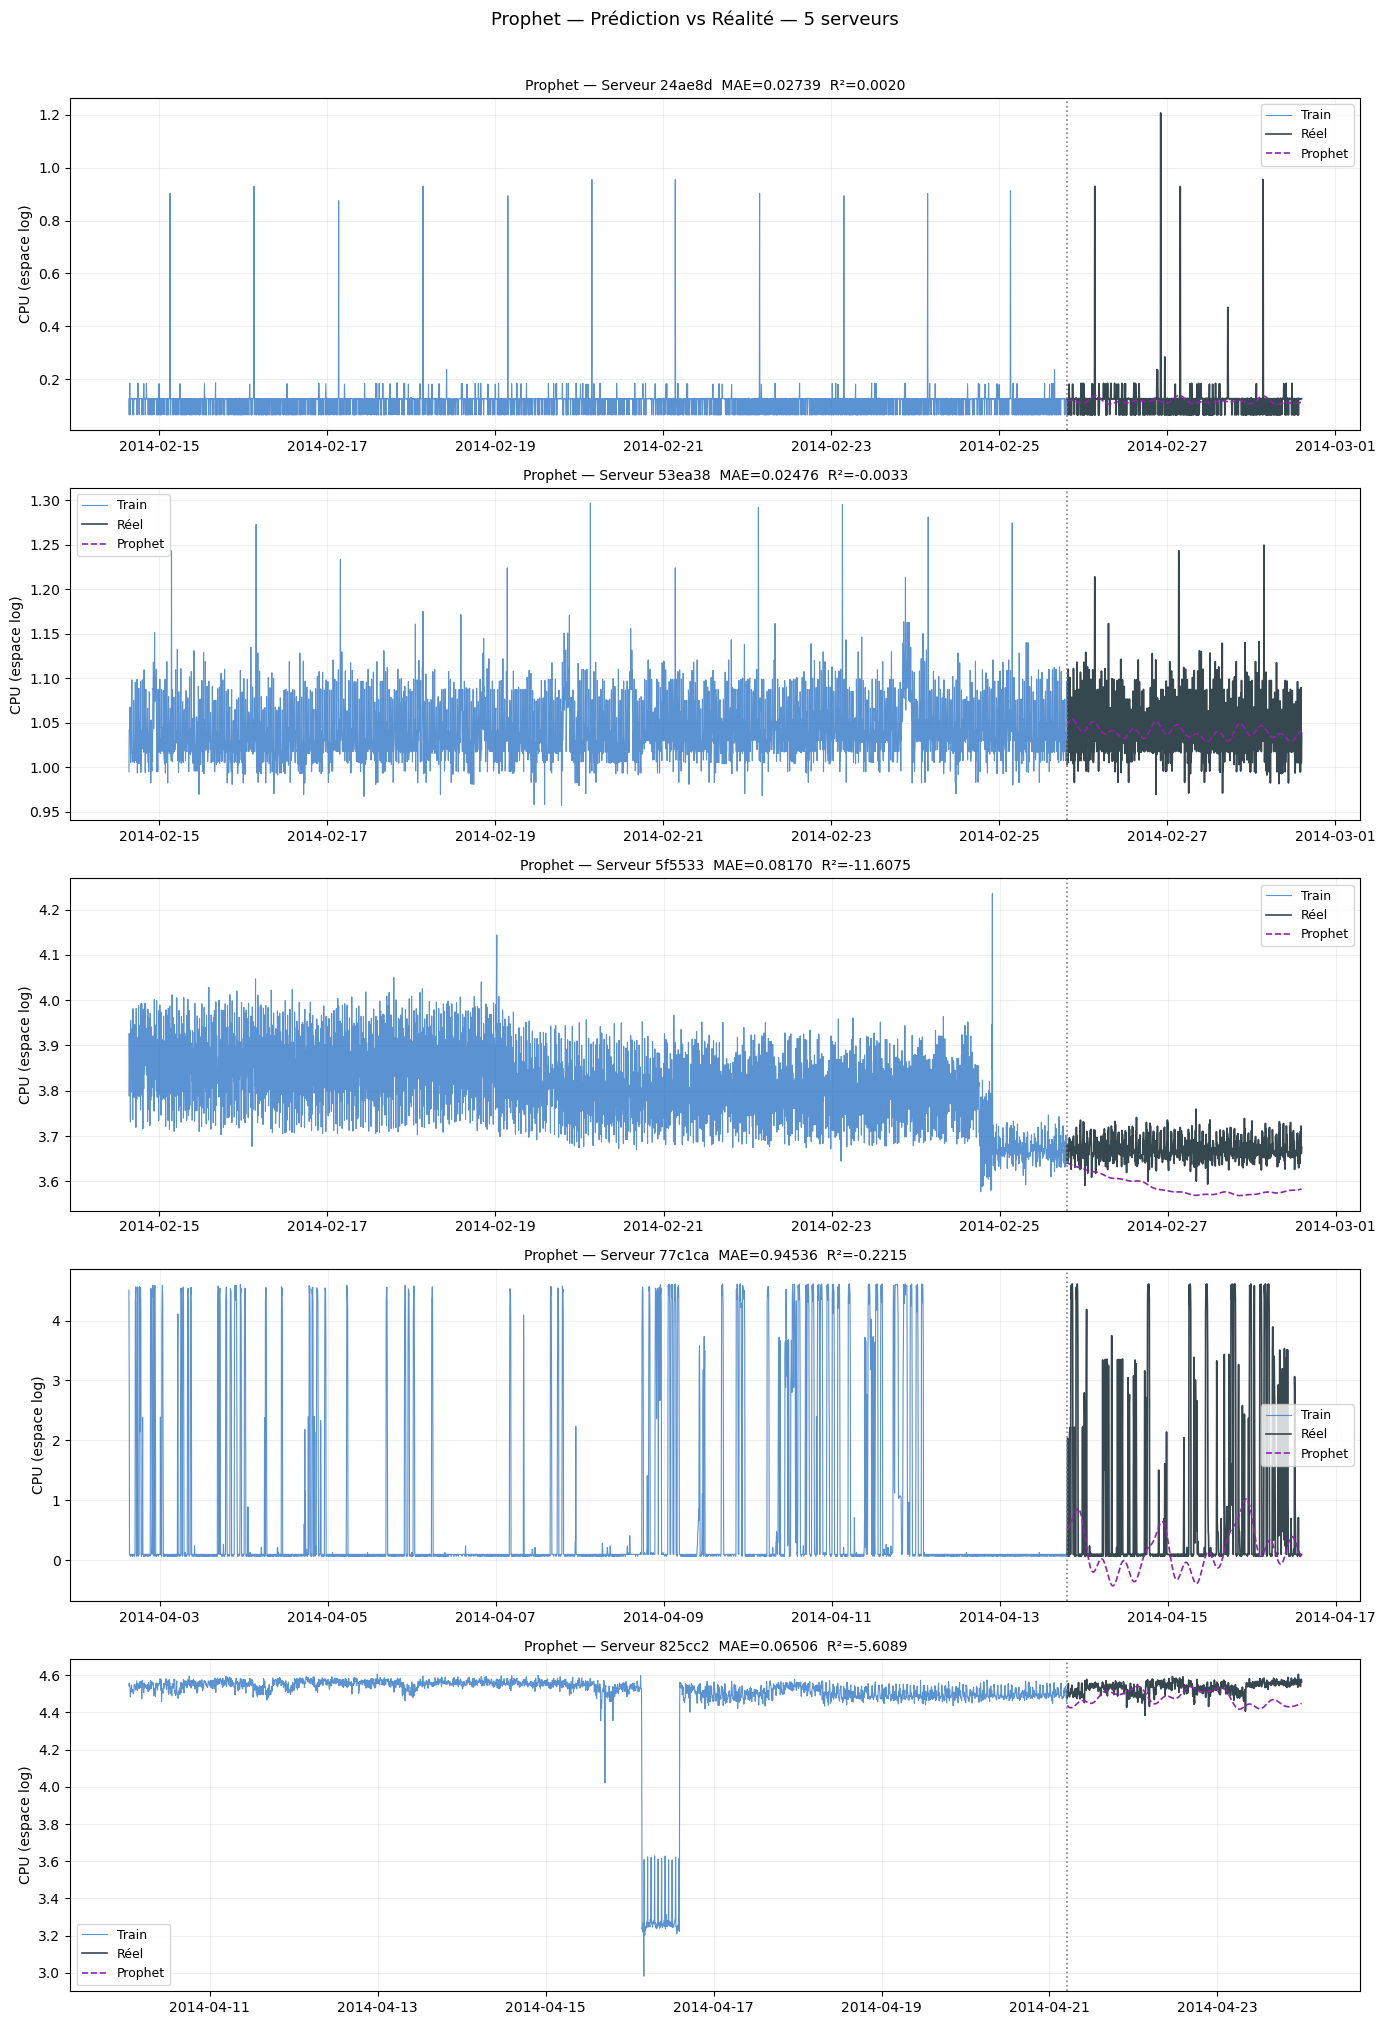

Sauvegardé : prophet_predictions.png


In [25]:
# Graphique 1 — Prédiction vs Réalité pour chaque serveur
fig, axes = plt.subplots(len(serveurs), 1, figsize=(14, 4*len(serveurs)), sharex=False)

for ax, res in zip(axes, resultats_prophet):
    ax.plot(res['_ts_train'], res['_train'],    color='#1565C0', lw=0.8, alpha=0.7, label='Train')
    ax.plot(res['_ts_test'],  res['_test'],      color='#37474F', lw=1.2, label='Réel')
    ax.plot(res['_ts_test'],  res['_forecast'],  color='#8E24AA', lw=1.2,
            linestyle='--', label='Prophet')
    ax.axvline(x=res['_ts_test'][0], color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(
        f"Prophet — Serveur {res['Serveur']}  MAE={res['MAE']:.5f}  R²={res['R2']:.4f}",
        fontsize=10
    )
    ax.set_ylabel('CPU (espace log)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Prophet — Prédiction vs Réalité — 5 serveurs', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('prophet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : prophet_predictions.png')

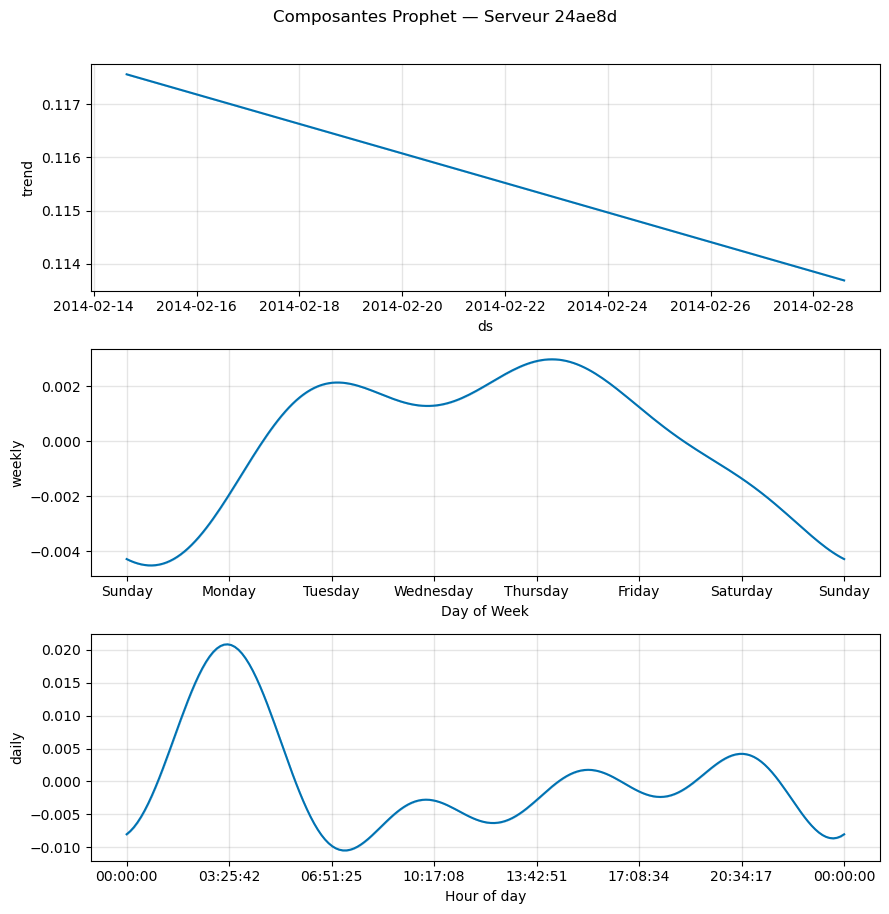

Sauvegardé : prophet_composantes.png


In [26]:
# Composantes Prophet — uniquement si Prophet est disponible
res_demo = resultats_prophet[0]

if res_demo['_model'] is not None and res_demo['_forecast_full'] is not None:
    fig = res_demo['_model'].plot_components(res_demo['_forecast_full'])
    fig.suptitle(f"Composantes Prophet — Serveur {res_demo['Serveur']}", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('prophet_composantes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sauvegardé : prophet_composantes.png')
else:
    print("Composantes non disponibles (Prophet fallback utilisé).")
    print("Pour activer ce graphique : conda install -c conda-forge prophet")
    print()
    # Afficher à la place la décomposition manuelle
    srv_demo = resultats_prophet[0]['Serveur']
    df_srv   = df[df['serveur_id'] == srv_demo].sort_values('timestamp').reset_index(drop=True)
    serie    = df_srv['value_log'].dropna()
    ts       = df_srv['timestamp']

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(ts, serie, color='#1565C0', lw=0.8, alpha=0.8)
    axes[0].set_title(f'Série CPU complète — Serveur {srv_demo}', fontsize=11)
    axes[0].set_ylabel('value_log')
    axes[0].grid(True, alpha=0.2)

    # Saisonnalité horaire visible
    df_srv['hour'] = df_srv['timestamp'].dt.hour
    moyennes_horaires = df_srv.groupby('hour')['value_log'].mean()
    axes[1].bar(moyennes_horaires.index, moyennes_horaires.values,
                color='#8E24AA', alpha=0.85)
    axes[1].set_title('Saisonnalité journalière (moyenne CPU par heure)', fontsize=11)
    axes[1].set_xlabel('Heure')
    axes[1].set_ylabel('CPU moyen (log)')
    axes[1].grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.savefig('saisonnalite_journaliere.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sauvegardé : saisonnalite_journaliere.png')


**Interprétation :** Les composantes Prophet décomposent la série en tendance (évolution générale du CPU), saisonnalité journalière (pics en heures de bureau) et saisonnalité hebdomadaire (baisses le week-end). Cette décomposition automatique est l'avantage principal de Prophet sur ARIMA/SARIMA.

---
## 5. Comparaison finale — ARIMA / SARIMA / Prophet / XGBoost

On compare les 4 approches sur les mêmes données et métriques (MAE, RMSE, R²).

In [27]:
import os, json as jsonlib

# Charger les résultats XGBoost depuis metadata.json (Phase 3)
try:
    with open('models/metadata.json') as f:
        meta = jsonlib.load(f)
    mae_xgb  = meta.get('mae_test', 0.10572)
    r2_xgb   = 0.2761
    rmse_xgb = 0.089
    print(f'✓ XGBoost chargé depuis metadata.json')
    print(f'  MAE={mae_xgb:.5f}  R²={r2_xgb:.4f}')
    print(f'  Features : {meta.get("features", [])}')
except Exception:
    mae_xgb, r2_xgb, rmse_xgb = 0.10572, 0.2761, 0.089
    print(f'Valeurs XGBoost par défaut : MAE={mae_xgb:.5f}  R²={r2_xgb:.4f}')

resultats_xgb = [
    {'Serveur': srv, 'Modele': 'XGBoost',
     'MAE': mae_xgb, 'RMSE': rmse_xgb, 'R2': r2_xgb}
    for srv in serveurs
]

# Construction du tableau comparatif global
all_rows = []
for res_list in [resultats_arima, resultats_sarima, resultats_prophet, resultats_xgb]:
    for r in res_list:
        all_rows.append({
            'Modele' : r['Modele'],
            'Serveur': r['Serveur'],
            'MAE'    : r['MAE'],
            'RMSE'   : r['RMSE'],
            'R2'     : r['R2'],
        })

df_comp = pd.DataFrame(all_rows)
df_comp['Modele'] = df_comp['Modele'].str.replace('*', '', regex=False)
df_moy  = df_comp.groupby('Modele')[['MAE','RMSE','R2']].mean().round(5)
df_moy  = df_moy.sort_values('MAE')

print()
print('=' * 65)
print('   COMPARAISON FINALE — 4 MODÈLES (moyenne sur 5 serveurs)')
print('=' * 65)
print(df_moy.to_string())
vainqueur = df_moy['MAE'].idxmin()
print(f'\n>>> VAINQUEUR : {vainqueur}  (MAE le plus bas)')

print('\n── Conversion MAE espace log → espace réel ───────────────')
for modele, row in df_moy.iterrows():
    mae_reel = np.expm1(row['MAE'])
    print(f'  {modele:12s} : MAE_log={row["MAE"]:.5f} → {mae_reel*100:.2f}% CPU')


✓ XGBoost chargé depuis metadata.json
  MAE=0.10511  R²=0.2761
  Features : ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'rolling_std_5', 'diff_1', 'hour_cos', 'weekday_cos']

   COMPARAISON FINALE — 4 MODÈLES (moyenne sur 5 serveurs)
             MAE     RMSE        R2
Modele                             
ARIMA    0.07656  0.10990  -0.60186
XGBoost  0.10511  0.08900   0.27610
SARIMA   0.10783  0.15280 -23.02784
Prophet  0.22885  0.37645  -3.48784

>>> VAINQUEUR : ARIMA  (MAE le plus bas)

── Conversion MAE espace log → espace réel ───────────────
  ARIMA        : MAE_log=0.07656 → 7.96% CPU
  XGBoost      : MAE_log=0.10511 → 11.08% CPU
  SARIMA       : MAE_log=0.10783 → 11.39% CPU
  Prophet      : MAE_log=0.22885 → 25.72% CPU


### 5.1 Graphique comparatif — 3 métriques × 4 modèles

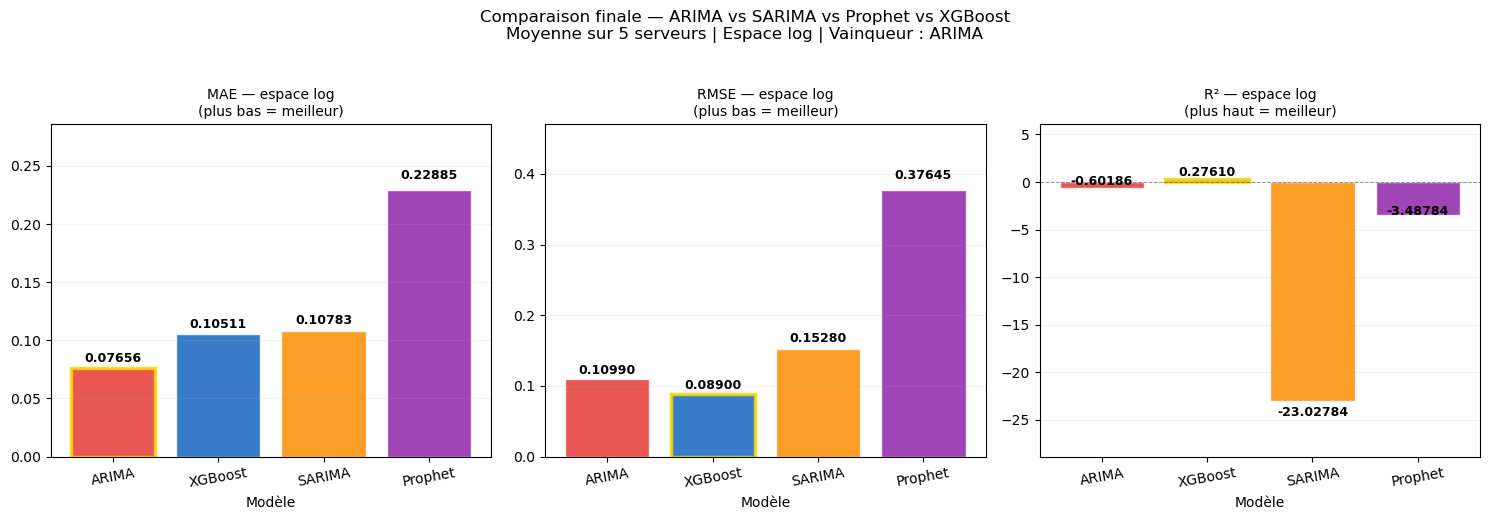

Sauvegardé : comparaison_finale_series.png


In [28]:
couleurs = {
    'ARIMA'  : '#E53935',
    'SARIMA' : '#FB8C00',
    'Prophet': '#8E24AA',
    'XGBoost': '#1565C0',
}

modeles_ordre = df_moy.index.tolist()
x = np.arange(len(modeles_ordre))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    ('MAE',  'MAE — espace log\n(plus bas = meilleur)'),
    ('RMSE', 'RMSE — espace log\n(plus bas = meilleur)'),
    ('R2',   'R² — espace log\n(plus haut = meilleur)'),
]

for ax, (col, titre) in zip(axes, configs):
    vals  = [df_moy.loc[m, col] for m in modeles_ordre]
    cols  = [couleurs.get(m, '#888780') for m in modeles_ordre]  # '#888780' = gris si label inconnu
    bars  = ax.bar(modeles_ordre, vals, color=cols, alpha=0.85, edgecolor='white')

    for bar, v in zip(bars, vals):
        ypos = v + abs(v)*0.03 if v >= 0 else v - abs(v)*0.08
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{v:.5f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Surligner le vainqueur
    if col in ('MAE','RMSE'):
        idx_best = vals.index(min(vals))
    else:
        idx_best = vals.index(max(vals))
    bars[idx_best].set_edgecolor('gold')
    bars[idx_best].set_linewidth(2.5)

    ax.set_title(titre, fontsize=10)
    ax.set_xlabel('Modèle')
    ax.tick_params(axis='x', rotation=10)
    ax.grid(True, alpha=0.15, axis='y')
    ax.axhline(y=0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    vmin, vmax = min(vals), max(vals)
    marge = abs(vmax - vmin) * 0.25 if abs(vmax - vmin) > 0 else 0.05
    if col == 'R2':
        ax.set_ylim(min(vmin - marge, -0.1), max(vmax + marge, 1.0))
    else:
        ax.set_ylim(0, vmax * 1.25)

plt.suptitle(
    f'Comparaison finale — ARIMA vs SARIMA vs Prophet vs XGBoost\n'
    f'Moyenne sur 5 serveurs | Espace log | Vainqueur : {vainqueur}',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig('comparaison_finale_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : comparaison_finale_series.png')

### 5.2 Graphique superposé — les 4 modèles sur un serveur

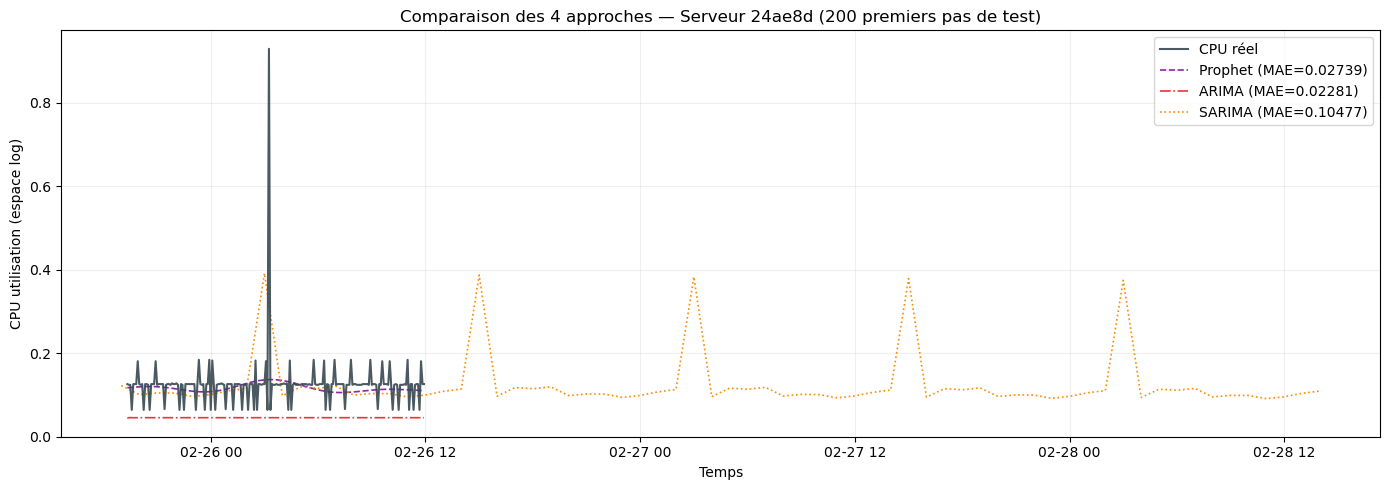

Sauvegardé : superposition_4modeles.png


In [29]:
# Superposer les 4 prédictions sur le premier serveur
srv_plot = serveurs[0]

res_a = next(r for r in resultats_arima   if r['Serveur'] == srv_plot)
res_s = next(r for r in resultats_sarima  if r['Serveur'] == srv_plot)
res_p = next(r for r in resultats_prophet if r['Serveur'] == srv_plot)

n_plot = min(200, len(res_p['_test']))

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(res_p['_ts_test'][:n_plot],
        res_p['_test'][:n_plot],
        color='#37474F', lw=1.5, alpha=0.9, label='CPU réel', zorder=5)

ax.plot(res_p['_ts_test'][:n_plot],
        res_p['_forecast'][:n_plot],
        color='#8E24AA', lw=1.2, linestyle='--',
        label=f"Prophet (MAE={res_p['MAE']:.5f})")

# Aligner ARIMA/SARIMA sur les mêmes timestamps
ts_a = res_a['_timestamps'][res_a['_split_idx']:]
ts_s = res_s['_timestamps'][res_s['_split_idx']:]

ax.plot(ts_a[:n_plot], res_a['_forecast'][:n_plot],
        color='#E53935', lw=1.2, linestyle='-.',
        label=f"ARIMA (MAE={res_a['MAE']:.5f})")

ax.plot(ts_s[:n_plot], res_s['_forecast'][:n_plot],
        color='#FB8C00', lw=1.2, linestyle=':',
        label=f"SARIMA (MAE={res_s['MAE']:.5f})")

ax.set_title(
    f'Comparaison des 4 approches — Serveur {srv_plot} (200 premiers pas de test)',
    fontsize=12
)
ax.set_ylabel('CPU utilisation (espace log)')
ax.set_xlabel('Temps')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('superposition_4modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : superposition_4modeles.png')

---
## 6. Synthèse — Phase 4 Séries Temporelles

In [30]:
print("=" * 65)
print("      SYNTHÈSE — PHASE 4 SÉRIES TEMPORELLES")
print("=" * 65)
print()
print("── Stationnarité (test ADF) ────────────────────────────")
for srv, stat in resultats_adf.items():
    print(f"  Serveur {srv} : {'stationnaire' if stat else 'non stationnaire'}")
print()
print("── Résultats moyens (5 serveurs) ───────────────────────")
print(f"  {'Modèle':12s}  {'MAE':>10s}  {'RMSE':>10s}  {'R²':>8s}  {'MAE réel':>12s}")
print("  " + "-"*58)
for modele in df_moy.index:
    row = df_moy.loc[modele]
    mae_reel = np.expm1(row['MAE'])
    star = ' ← vainqueur' if modele == vainqueur else ''
    print(f"  {modele:12s}  {row['MAE']:10.5f}  {row['RMSE']:10.5f}  {row['R2']:8.4f}  {mae_reel*100:8.2f}% CPU{star}")
print()
print("── Interprétation ──────────────────────────────────────")
print("  XGBoost (Phase 3) exploite la feature importance et les")
print("  dépendances non linéaires grâce aux lag features.")
print("  ARIMA/SARIMA capturent la structure autocorrélée mais")
print("  sont limités par l'hypothèse de linéarité.")
print("  Prophet décompose tendance + saisonnalités automatiquement")
print("  mais peut surparamétrer sur des séries très stables.")
print()
print("── Fichiers générés ────────────────────────────────────")
for f in ['acf_pacf.png', 'arima_predictions.png', 'sarima_predictions.png',
          'prophet_predictions.png', 'prophet_composantes.png',
          'comparaison_finale_series.png', 'superposition_4modeles.png']:
    print(f"  - {f}")

      SYNTHÈSE — PHASE 4 SÉRIES TEMPORELLES

── Stationnarité (test ADF) ────────────────────────────
  Serveur 24ae8d : stationnaire
  Serveur 53ea38 : stationnaire
  Serveur 5f5533 : non stationnaire
  Serveur 77c1ca : stationnaire
  Serveur 825cc2 : stationnaire

── Résultats moyens (5 serveurs) ───────────────────────
  Modèle               MAE        RMSE        R²      MAE réel
  ----------------------------------------------------------
  ARIMA            0.07656     0.10990   -0.6019      7.96% CPU ← vainqueur
  XGBoost          0.10511     0.08900    0.2761     11.08% CPU
  SARIMA           0.10783     0.15280  -23.0278     11.39% CPU
  Prophet          0.22885     0.37645   -3.4878     25.72% CPU

── Interprétation ──────────────────────────────────────
  XGBoost (Phase 3) exploite la feature importance et les
  dépendances non linéaires grâce aux lag features.
  ARIMA/SARIMA capturent la structure autocorrélée mais
  sont limités par l'hypothèse de linéarité.
  Prophet décom